In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import os, sys
from pathlib import Path
import functools

from extra.components import XrayPulses
import extra_data as ex
from extra_data.components import AGIPD1M
from extra_geom import AGIPD_1MGeometry
from extra_data import by_index
import extra_speckle as esp
from extra_speckle.setup import Setup

from dask_jobqueue import SLURMCluster
from dask.distributed import Client
import dask.array as da

import numpy as np
import matplotlib.pyplot as plt
import h5py
from pyFAI.integrator.azimuthal import AzimuthalIntegrator

import damnit

In [2]:
db = damnit.Damnit(10400)

In [61]:
run_nr = 424
bg_run_nr = 464

In [62]:
data = db[run_nr]["agipd_saxs"].read()
data_bg = db[bg_run_nr]["agipd_saxs"].read()

In [63]:
mean_bg = data_bg.mean(["trainId", "pulseId"])

In [64]:
def plot_saxs_series(dataset, ax, step=100, bg=None):
    q = dataset.q.values
    pulse = dataset.pulseId.values
    for i in range(0, len(dataset.trainId), step):
        iq = dataset.isel(trainId=i).data.mean(0)
        if bg is not None:
            iq -= bg
        ax.loglog(q, iq)
    return ax

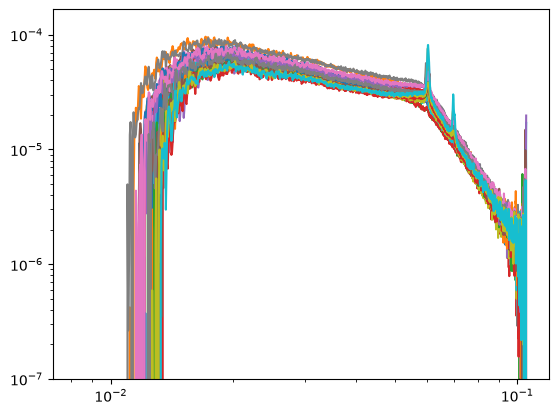

In [65]:
fig, ax = plt.subplots()
# ax.loglog(mean_bg.q, mean_bg.data)
# ax.loglog(data.q, data.isel(trainId=0).data.mean(0) - mean_bg.data)
plot_saxs_series(data, ax=ax, bg=mean_bg.data)
ax.set_ylim(1e-7)
plt.show()